In [93]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [94]:
# Leitura do arquivo

caminho_arquivo = 'tratados_10x10det/photon/photon1E17_array'

df = pl.read_csv(caminho_arquivo, has_header= False).filter(pl.col('column_1').str.contains('TRIG'))

df = df.with_columns(pl.col("column_1").str.split(" ").alias("split_column"))
df = df.with_columns(pl.col("split_column").list.get(0).alias("TRIG"))
df = df.with_columns(pl.col("split_column").list.get(1).cast(pl.Int64).alias("positrons"))
df = df.with_columns(pl.col("split_column").list.get(2).cast(pl.Int64).alias("electrons"))
df = df.with_columns(pl.col("split_column").list.get(3).cast(pl.Int64).alias("muons_plus"))
df = df.with_columns(pl.col("split_column").list.get(4).cast(pl.Int64).alias("muons_minus"))
df = df.with_columns(
    (pl.col("positrons") + pl.col("electrons") + pl.col("muons_plus") + pl.col("muons_minus")).alias("total_particles")
)

df

column_1,split_column,TRIG,positrons,electrons,muons_plus,muons_minus,total_particles
str,list[str],str,i64,i64,i64,i64,i64
"""TRIG1 0 0 0 0""","[""TRIG1"", ""0"", … ""0""]","""TRIG1""",0,0,0,0,0
"""TRIG2 0 0 0 0""","[""TRIG2"", ""0"", … ""0""]","""TRIG2""",0,0,0,0,0
"""TRIG3 0 450 0 0""","[""TRIG3"", ""0"", … ""0""]","""TRIG3""",0,450,0,0,450
"""TRIG4 0 0 0 0""","[""TRIG4"", ""0"", … ""0""]","""TRIG4""",0,0,0,0,0
"""TRIG5 0 565 0 0""","[""TRIG5"", ""0"", … ""0""]","""TRIG5""",0,565,0,0,565
…,…,…,…,…,…,…,…
"""TRIG96 0 0 0 0""","[""TRIG96"", ""0"", … ""0""]","""TRIG96""",0,0,0,0,0
"""TRIG97 0 0 0 0""","[""TRIG97"", ""0"", … ""0""]","""TRIG97""",0,0,0,0,0
"""TRIG98 966 0 0 0""","[""TRIG98"", ""966"", … ""0""]","""TRIG98""",966,0,0,0,966


In [95]:
import re
def formatar_string(s):

    nome_arquivo = s.split('/')[-1]
   
    match = re.match(r'([a-zA-Z]+)([0-9]+(?:\.[0-9]+)?[Ee][0-9]+)', nome_arquivo)

    if match:
        
        palavra = match.group(1).capitalize()
        numero = match.group(2)

        return f'{palavra} {numero}'
    else:
        return nome_arquivo

name = formatar_string(caminho_arquivo)
name

'Photon 1E17'

In [96]:
# Posição dos tanques

numDetectors = 100
gridSize = 10
spacing = 10
area = 1.0

x_det = np.zeros(numDetectors)
y_det = np.zeros(numDetectors)
areas = np.full(numDetectors, area)

index = 0
halfGridSize = gridSize // 2

for i in range(gridSize):
    for j in range(gridSize):
        x_det[index] = (j - halfGridSize + 0.5) * spacing
        y_det[index] = (i - halfGridSize + 0.5) * spacing
        areas[index] = area
        index += 1

#print("x_det:", x_det)
#print("y_det:", y_det)
#print("areas:", areas)

In [97]:
from scipy.spatial import KDTree

df2 = df.group_by('TRIG').agg(pl.col('total_particles')).sort(
    pl.col('TRIG').str.extract(r"TRIG([0-9]*)", 1).cast(int)
)

# Método KDTree 
positions = np.column_stack((x_det, y_det))
tree = KDTree(positions)
d_max = 15  # Distância máxima para considerar como próximos

# Validar simulações com triangulação
num_simulations = len(df2["total_particles"][0])

valid_simulations = []

for sim_idx in range(num_simulations):
    detections = np.array([df2["total_particles"][i][sim_idx] > 0 for i in range(100)])  

    detected_indices = np.where(detections)[0]
    if len(detected_indices) < 3:
        continue
    
    neighbors = []
    for tank in detected_indices:
        neighbors.append(set(tree.query_ball_point(positions[tank], d_max)))
    
    valid = False
    n = len(detected_indices)
    for i in range(n):
        tank_i = detected_indices[i]
        for j in range(i + 1, n):
            tank_j = detected_indices[j]
            if tank_j not in neighbors[i]:  
                continue
            for k in range(j + 1, n):
                tank_k = detected_indices[k]
                if tank_k in neighbors[i] and tank_k in neighbors[j]:
                    valid = True
                    break
            if valid:
                break
        if valid:
            break
    
    if valid:
        valid_simulations.append(sim_idx)


# Atualizar o dataframe
triangulation_particles = [
    [particles[i] for i in valid_simulations] for particles in df2["total_particles"]
]

triangulation_particles = df2.with_columns(
    pl.Series("triangulation_particles", triangulation_particles)
)

print(f"Simulações válidas: {len(valid_simulations)}")
triangulation_particles

Simulações válidas: 723


TRIG,total_particles,triangulation_particles
str,list[i64],list[i64]
"""TRIG1""","[0, 0, … 0]","[0, 0, … 0]"
"""TRIG2""","[0, 599, … 0]","[0, 599, … 0]"
"""TRIG3""","[450, 413, … 0]","[450, 413, … 0]"
"""TRIG4""","[0, 0, … 0]","[0, 0, … 0]"
"""TRIG5""","[565, 0, … 0]","[565, 0, … 0]"
…,…,…
"""TRIG96""","[0, 0, … 0]","[0, 0, … 0]"
"""TRIG97""","[0, 0, … 0]","[0, 0, … 0]"
"""TRIG98""","[1194, 916, … 966]","[1194, 916, … 966]"


In [98]:
triangulation_particles = triangulation_particles.with_columns(mean_particles = pl.col('triangulation_particles').list.mean())  
trigs = triangulation_particles['mean_particles'].to_list()
triangulation_particles

TRIG,total_particles,triangulation_particles,mean_particles
str,list[i64],list[i64],f64
"""TRIG1""","[0, 0, … 0]","[0, 0, … 0]",156.49101
"""TRIG2""","[0, 599, … 0]","[0, 599, … 0]",222.720609
"""TRIG3""","[450, 413, … 0]","[450, 413, … 0]",297.113416
"""TRIG4""","[0, 0, … 0]","[0, 0, … 0]",332.64177
"""TRIG5""","[565, 0, … 0]","[565, 0, … 0]",380.704011
…,…,…,…
"""TRIG96""","[0, 0, … 0]","[0, 0, … 0]",346.587828
"""TRIG97""","[0, 0, … 0]","[0, 0, … 0]",346.027663
"""TRIG98""","[1194, 916, … 966]","[1194, 916, … 966]",297.883817


Text(62.722222222222214, 0.5, 'y (m)')

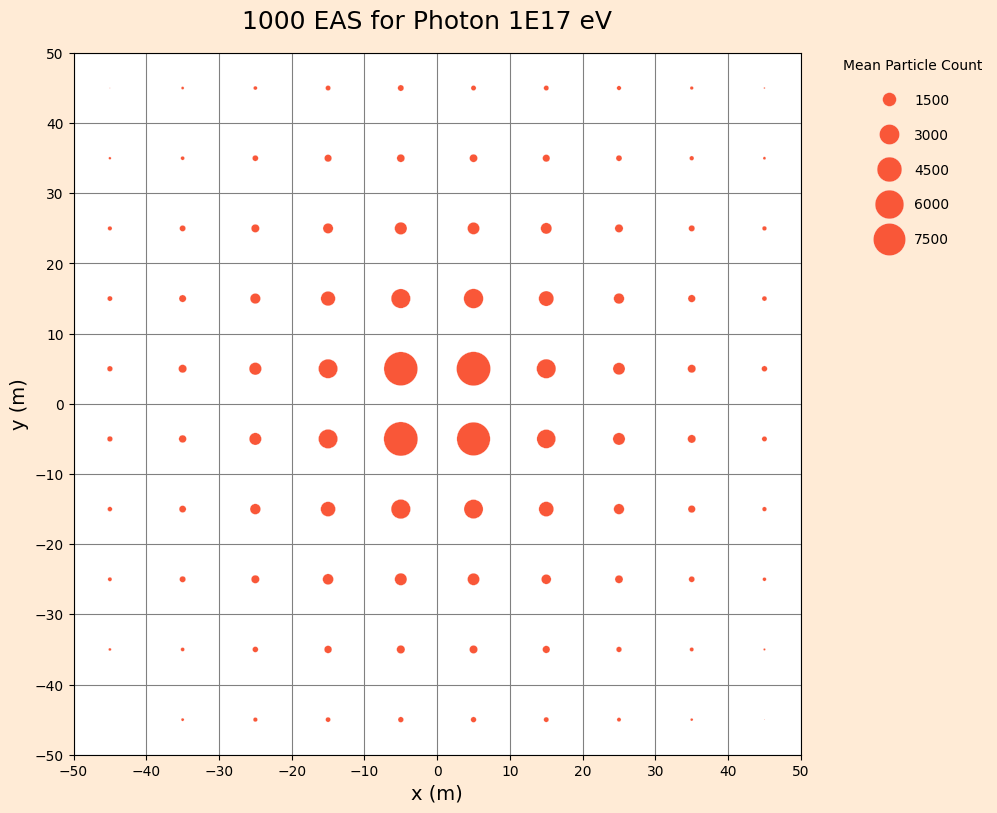

In [99]:
# Plot de partículas por tanque
fig, ax = plt.subplots(1, 1, figsize = (8, 8), facecolor = '#FFEBD6')
fig.suptitle('1000 EAS for ' + str(name) + ' eV', size = 18)
fig.tight_layout()
ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='-')
ax.xaxis.grid(color='gray', linestyle='-')

scatter = sns.scatterplot(x = x_det, y = y_det, ax = ax, color = '#F95738', size=trigs, sizes=(0, 600), legend = 'brief')
handles, labels = scatter.get_legend_handles_labels()
for handle in handles:
    handle.set_color('#F95738')
ax.legend(handles=handles, labels=labels, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.,
           frameon=False, title='Mean Particle Count', labelspacing = 1.5)

plt.xticks(ticks=[-50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50])
plt.yticks(ticks=[-50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50])
ax.set_xlabel('x (m)', size = 14)
ax.set_ylabel('y (m)', size = 14)


#plt.savefig('plots/' + name.split(' ')[0].lower() + '/counts_' + caminho_arquivo.split('/')[-1].split('_')[0] + '.png', bbox_inches = 'tight', dpi = 300)

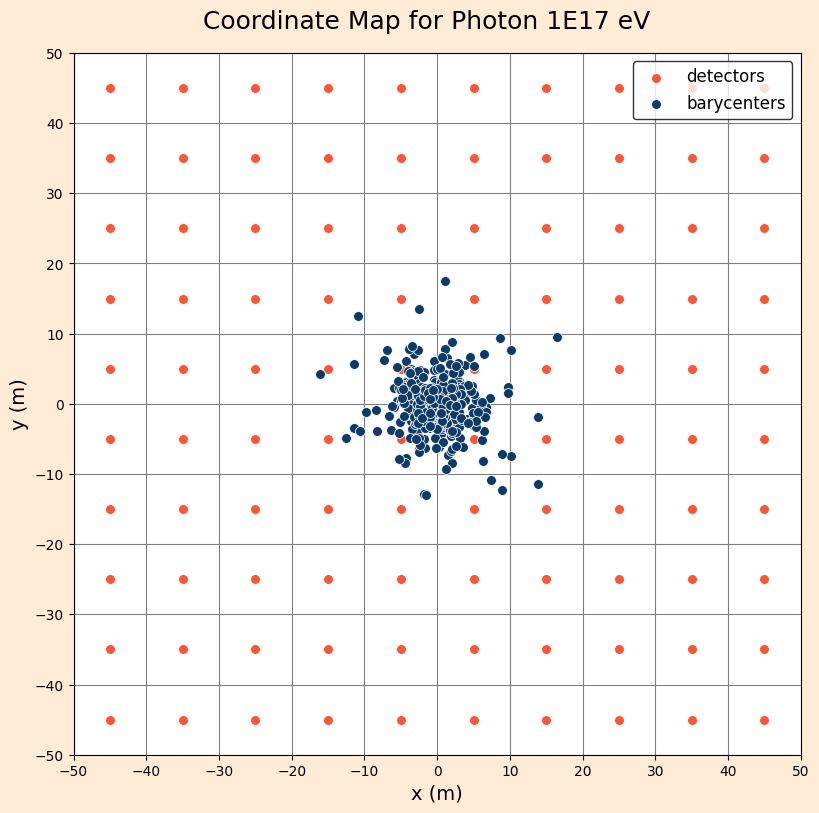

In [100]:
# Posição dos baricentros
x_b = [0] * len(valid_simulations)
y_b = [0] * len(valid_simulations)
rho = []

for i in range(len(valid_simulations)):
        numerator = 0
        numerator1 = 0
        denominator = 0
        for j in range(len(trigs)):
                numerator += (triangulation_particles['triangulation_particles'][j][i]*x_det[j])
                numerator1 += (triangulation_particles['triangulation_particles'][j][i]*y_det[j])
                denominator += (triangulation_particles['triangulation_particles'][j][i])
                rho.append((triangulation_particles['triangulation_particles'][j][i])/1)
                if denominator != 0: 
                    x_b[i] = numerator / denominator
                    y_b[i] = numerator1 / denominator
                else:
                    x_b[i] = 0 
                    y_b[i] = 0 

fig, ax = plt.subplots(1, 1, figsize = (8, 8), facecolor = '#FFEBD6')
fig.suptitle('Coordinate Map for ' + str(name) + ' eV', size = 18)
fig.tight_layout()
ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='-')
ax.xaxis.grid(color='gray', linestyle='-')

sns.scatterplot(x = x_det, y = y_det, ax = ax, color = '#F95738', s = 50)
sns.scatterplot(x = x_b, y = y_b, ax = ax, color = '#0D3B66',s = 50)

plt.xticks(ticks=[-50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50])
plt.yticks(ticks=[-50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50])
ax.set_xlabel('x (m)', size = 14)
ax.set_ylabel('y (m)', size = 14)


ax.legend(['detectors', 'barycenters'], edgecolor = 'black', fontsize = 12, loc = 1)

#plt.savefig('plots/' + name.split(' ')[0].lower() + '/map_' + caminho_arquivo.split('/')[-1].split('_')[0] + '.png',bbox_inches = 'tight', dpi = 300)

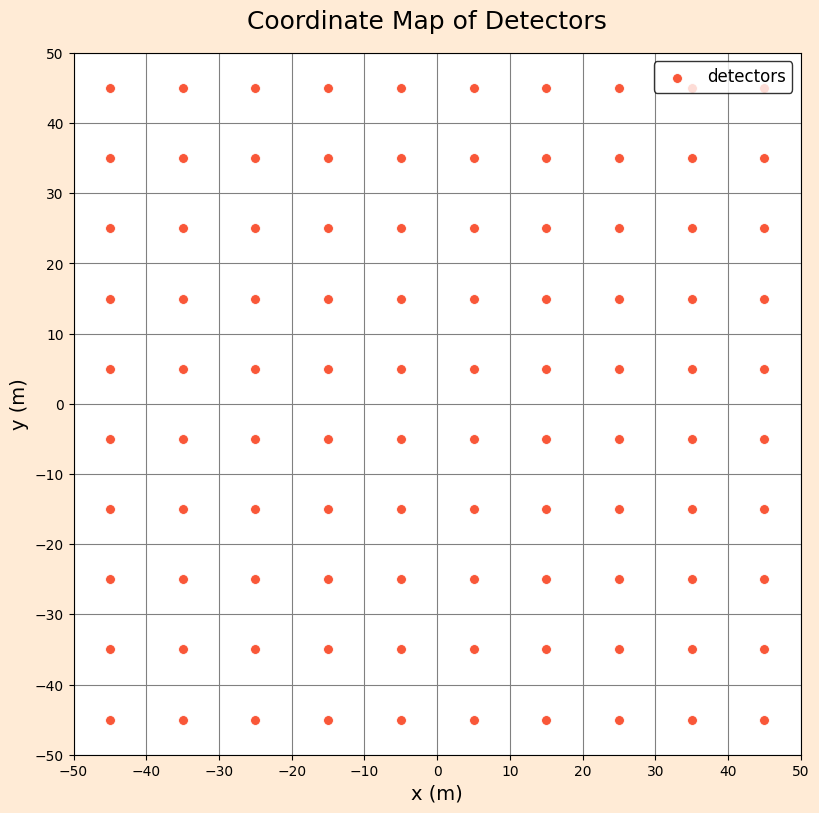

In [101]:
fig, ax = plt.subplots(1, 1, figsize = (8, 8), facecolor = '#FFEBD6')
fig.suptitle('Coordinate Map of Detectors', size = 18)
fig.tight_layout()
ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='-')
ax.xaxis.grid(color='gray', linestyle='-')

sns.scatterplot(x = x_det, y = y_det, ax = ax, color = '#F95738', s = 50)

plt.xticks(ticks=[-50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50])
plt.yticks(ticks=[-50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50])
ax.set_xlabel('x (m)', size = 14)
ax.set_ylabel('y (m)', size = 14)


ax.legend(['detectors'], edgecolor = 'black', fontsize = 12, loc = 1)

In [102]:
#i = 4
#eas = 1000
#area_detectores = 100
#area_total = (np.pi*100**2)
#total_particles = [2.070011e+07, 3.399932e+07, 5.00261e+08, 2.16563e+09, 1.01274e+10]
#part = total_particles[i]/eas * (area_detectores/area_total)
#part

[7.42780581e+05 1.29198737e+00]
[1.75351512 2.56888255 3.27503513 3.89085924 4.41399326]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_25436\1815926346.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'


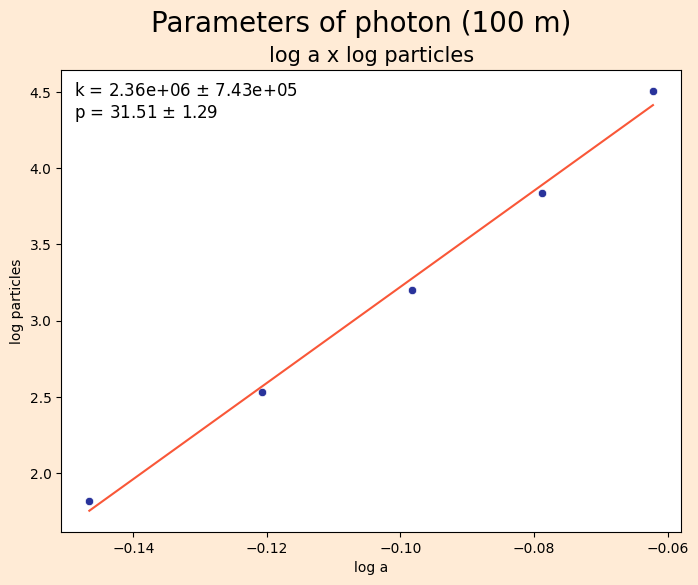

In [103]:
from scipy.optimize import curve_fit

# Fit do fóton

a = [0.7135, 0.7573, 0.7974, 0.8341, 0.8666]
total_particles = [2.070011e+07, 3.399932e+07, 5.00261e+08, 2.16563e+09, 1.01274e+10]
particles = [65.89049658091947, 342.47847087108477, 1592.3802197218931, 6893.414388162026, 32236.515413377216]

E = [1E15, 3.16E15, 1E16, 3.16E16, 1E17]

loga = np.log10(a)
logparticles = np.log10(particles)
#logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of photon (100 m)', size = 20)
#fig.tight_layout()


ax.set_title('log a x log particles', size = 15)
ax.set_xlabel('log a')
ax.set_ylabel('log particles')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_photon, cov = curve_fit(power, a, np.log10(particles), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(a,*coefficients_photon))

ax.plot(loga, power(a,*coefficients_photon), color = '#F95738')
sns.scatterplot(x = loga, y = logparticles, color = '#29339B', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_photon[0],inc[0],coefficients_photon[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)

In [104]:
r_b = [] 

# Estruturação da lista rho para 100 tanques
rho_reshaped = np.array(rho).reshape(len(x_b), 100)


for i in range(len(valid_simulations)):
    #aux = ((x_det[i]-x_b[i])**2 + (y_det[i]-y_b[i])**2)**0.5
    aux = x_b[i]** 2 + y_b[i]**2
    r_b.append(aux)

data = {
    'x_b':x_b,
    'y_b':y_b,
    'r_b':r_b
}

for i in range(100):
    data[f'rho_{i+1}'] = rho_reshaped[:, i].tolist()

df = pl.DataFrame(data, strict=False)

rho_cols = [pl.col(f'rho_{i+1}') for i in range(100)]

df = df.with_columns(
    rho_total=pl.sum_horizontal(rho_cols)        
)

df = df.with_columns(
    particles_total=pl.col('rho_total') * 1
)

df = df.with_columns(
    a=(pl.col("particles_total") / coefficients_photon[0]).pow(1 / coefficients_photon[1])
)

distance_bary = []
for i in range(100):
    x = x_det[i]
    y = y_det[i]
    expr = ((pl.col("x_b") - x)**2 + (pl.col("y_b") - y)**2).sqrt().alias(f"r{i+1}_b")
    distance_bary.append(expr)

df = df.with_columns(distance_bary)

# Reordenar colunas
df = df.select([
    'x_b', 
    'y_b', 
    'r_b', 
    'rho_total', 
    'particles_total', 
    'a',
    *[f'r{i+1}_b' for i in range(100)],
    *[f'rho_{i+1}' for i in range(100)]
])

df

x_b,y_b,r_b,rho_total,particles_total,a,r1_b,r2_b,r3_b,r4_b,r5_b,r6_b,r7_b,r8_b,r9_b,r10_b,r11_b,r12_b,r13_b,r14_b,r15_b,r16_b,r17_b,r18_b,r19_b,r20_b,r21_b,r22_b,r23_b,r24_b,r25_b,r26_b,r27_b,r28_b,r29_b,r30_b,r31_b,…,rho_64,rho_65,rho_66,rho_67,rho_68,rho_69,rho_70,rho_71,rho_72,rho_73,rho_74,rho_75,rho_76,rho_77,rho_78,rho_79,rho_80,rho_81,rho_82,rho_83,rho_84,rho_85,rho_86,rho_87,rho_88,rho_89,rho_90,rho_91,rho_92,rho_93,rho_94,rho_95,rho_96,rho_97,rho_98,rho_99,rho_100
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
-2.357951,2.067517,9.834559,21313.0,21313.0,0.861212,63.511382,57.278745,52.23039,48.735743,47.141612,47.639171,50.16622,54.440873,60.091328,66.769205,56.500843,49.391338,43.435737,39.164043,37.161556,37.790743,40.93042,46.070146,52.627154,60.13964,50.507375,42.404645,35.288991,29.874268,27.196156,28.049776,32.155077,38.485165,46.133144,54.547465,45.930867,…,1467.0,0.0,477.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,545.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1064.0,0.0,0.0,417.0,0.0,0.0,0.0,0.0,0.0,417.0,0.0,0.0,0.0,1194.0,0.0,0.0
0.571829,1.337779,2.116641,151916.0,151916.0,0.916594,64.992164,58.41699,52.925497,48.884267,46.671565,46.548882,48.53207,52.38249,57.727712,64.195421,58.285725,50.850656,44.433688,39.533733,36.762473,36.606596,39.097395,43.785496,50.057298,57.395963,52.635256,44.260972,36.709631,30.596739,26.920696,26.707439,30.030829,35.922335,43.347175,51.648243,48.411927,…,1480.0,6198.0,1590.0,3395.0,1483.0,4477.0,838.0,0.0,570.0,2619.0,1787.0,3561.0,2999.0,2431.0,0.0,0.0,0.0,959.0,586.0,0.0,0.0,1804.0,504.0,0.0,456.0,0.0,0.0,1128.0,0.0,0.0,734.0,720.0,0.0,0.0,916.0,0.0,586.0
1.622565,-2.423482,8.505983,73316.0,73316.0,0.895647,63.13813,56.160237,50.214748,45.706341,43.088493,42.710268,44.628642,48.572259,54.100028,60.781261,56.876121,49.01471,42.071255,36.572383,33.242862,32.751131,35.216265,40.096558,46.639926,54.24787,51.801185,43.022221,34.906449,28.035849,23.527804,22.827751,26.242236,32.499286,40.29581,48.900931,48.289051,…,530.0,2220.0,514.0,1023.0,1464.0,697.0,0.0,0.0,0.0,0.0,1088.0,769.0,676.0,471.0,1215.0,0.0,0.0,0.0,0.0,606.0,716.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,760.0,0.0,435.0,0.0,0.0
1.492822,-1.190731,3.646357,339766.0,339766.0,0.940308,63.88141,57.017349,51.196891,46.810952,44.287795,43.949429,45.844257,49.717597,55.154175,61.742421,57.486077,49.747288,42.952721,37.617547,34.427073,33.990689,36.407561,41.178321,47.600396,55.099376,52.234699,43.573011,35.619529,28.963674,24.678695,24.066192,27.373804,33.458463,41.104894,49.595926,48.500292,…,5887.0,11169.0,9511.0,5207.0,3833.0,1933.0,445.0,575.0,493.0,435.0,5723.0,637.0,4783.0,2124.0,1186.0,958.0,499.0,992.0,1367.0,957.0,1853.0,1315.0,447.0,1971.0,1294.0,426.0,956.0,519.0,0.0,490.0,0.0,544.0,608.0,0.0,509.0,0.0,1668.0
1.149756,-0.918367,2.165337,27832.0,27832.0,0.868537,63.819983,57.008729,51.254269,46.946831,44.508537,44.24946,46.206272,50.120101,55.579037,62.177442,57.370355,49.682618,42.95774,37.714351,34.632025,34.298427,36.788408,41.597979,48.03537,55.537389,52.055019,43.436504,35.549047,28.995511,24.854467,24.387485,27.780466,33.89335,41.542317,50.027682,48.250309,…,482.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,991.0,991.0,0.0,1500.0,0.0,863.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,838.0,0.0,641.0,0.0,0.0,0.0,473.0,0.0,0.0,0.0,0.0,0.0,0.0,611.0,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
-1.024581,0.649231,1.471267,456694.0,456694.0,0.949175,63.385249,56.905021,51.562322,47.740597,45.822006,46.045064,48.380156,52.546466,58.151722,64.823718,56.610115,49.246287,42.961476,38.29073,35.870205,36.154713,39.085226,44.137813,50.681734,58.216233,50.908944,42.570085,35.109881,29.209509,25.955481,26.3

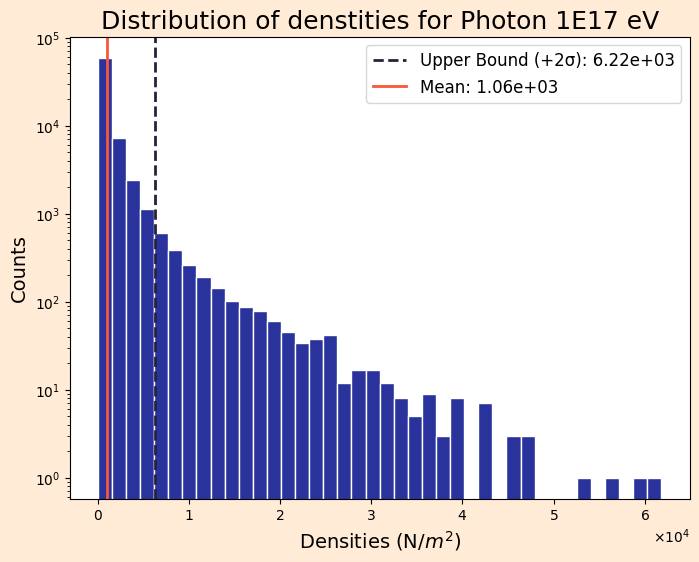

In [105]:

rho_columns = [f"rho_{i+1}" for i in range(100)] 
values = df.select(rho_columns).to_numpy().flatten()  

fig, ax = plt.subplots(figsize=(8, 6), facecolor='#FFEBD6')
plt.hist(values, color='#29339B', bins=40, edgecolor='white')
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0), useMathText=True)
ax.set_yscale('log')


plt.title('Distribution of denstities for ' + str(name) + ' eV', size=18)  

# Calcula a média e o desvio padrão dos dados
mean = values.mean()
std = values.std()

# Determina os limites de 2 sigma
#lower_bound = mean - 2 * std
upper_bound = mean + 2 * std


# Adiciona linhas verticais para os limites de 2 sigma
#ax.axvline(lower_bound, color='#548C2F', linestyle='--', linewidth=2, label=f'Lower Bound (-2σ): {lower_bound:.2f}')
ax.axvline(upper_bound, color='#27213C', linestyle='--', linewidth=2, label=f'Upper Bound (+2σ): {upper_bound:.2e}')
ax.axvline(mean, color='#F95738', linestyle='-', linewidth=2, label=f'Mean: {mean:.2e}')

# Personaliza o eixo e a legenda
ax.set_xlabel('Densities (N/$m^2$)', size=14)
ax.set_ylabel('Counts', size=14)
ax.legend(loc='upper right', fontsize=12)

#plt.savefig('plots/' + name.split(' ')[0].lower() + '/densities_' + caminho_arquivo.split('/')[-1] + '_array.png', bbox_inches = 'tight')


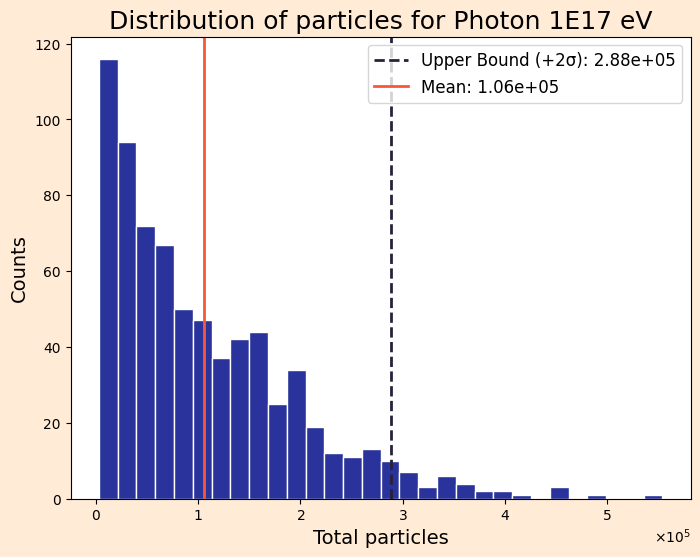

In [106]:
values = df.select('particles_total').to_numpy().flatten()  

fig, ax = plt.subplots(figsize=(8, 6), facecolor='#FFEBD6')
plt.hist(values, color='#29339B', bins=30, edgecolor='white')
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0), useMathText=True)


plt.title('Distribution of particles for ' + str(name) + ' eV', size=18)  

# Calcula a média e o desvio padrão dos dados
mean = values.mean()
std = values.std()

# Determina os limites de 2 sigma
#lower_bound = mean - 2 * std
upper_bound = mean + 2 * std


# Adiciona linhas verticais para os limites de 2 sigma
#ax.axvline(lower_bound, color='#548C2F', linestyle='--', linewidth=2, label=f'Lower Bound (-2σ): {lower_bound:.2f}')
ax.axvline(upper_bound, color='#27213C', linestyle='--', linewidth=2, label=f'Upper Bound (+2σ): {upper_bound:.2e}')
ax.axvline(mean, color='#F95738', linestyle='-', linewidth=2, label=f'Mean: {mean:.2e}')

# Personaliza o eixo e a legenda
ax.set_xlabel('Total particles', size=14)
ax.set_ylabel('Counts', size=14)
ax.legend(loc='upper right', fontsize=12)

#plt.savefig('plots/' + name.split(' ')[0].lower() + '/densities_' + caminho_arquivo.split('/')[-1] + '_array.png', bbox_inches = 'tight')


In [107]:
# Modelagem NKG
def model(r, C, a, b):
    r0 = 78
    return C/(r0**2)*(r/r0)**(-a)*(1+r/r0)**(-b)


parameters = []
uncertainties = []
r_squared_list = []
rmse_list = []

x_cols = [f"r{i+1}_b" for i in range(100)]  
y_cols = [f"rho_{i+1}" for i in range(100)] 

x = df.select(x_cols).to_numpy()
y = df.select(y_cols).to_numpy()

a_std = df['a'].std()

#for i in range(len(x)):
#    print(f"Linha {i}: x = {x[i]}, y = {y[i]}")

for i in range(len(x)):
    r = x[i].flatten()  
    rho = y[i].flatten()
    a_fixed = df['a'][i]

    try:
        
        def current_model(r, C, b):
            return model(r, C, a_fixed, b)
        
        popt, pcov = curve_fit(current_model, r, rho, p0= [1E5, 3] , bounds= ([0, 2.5], [np.inf, 4.0]))
        perr = np.sqrt(np.diag(pcov))

        # Cálculo das métricas
        y_pred = current_model(r, *popt)

        # R²
        ss_res = np.sum((rho - y_pred)**2)
        ss_tot = np.sum((rho - np.mean(rho))**2)
        r_sq = 1 - (ss_res/ss_tot) if ss_tot != 0 else np.nan

        # RMSE
        rmse = np.sqrt(np.mean((rho - y_pred)**2))

        parameters.append([popt[0], a_fixed, popt[1]])
        uncertainties.append([perr[0], a_std, perr[1]])
        #parameters.append(popt)
        #uncertainties.append(perr)
        r_squared_list.append(r_sq)
        rmse_list.append(rmse)
    except RuntimeError:
        parameters.append([np.nan, np.nan])
        uncertainties.append([np.nan, np.nan])
        r_squared_list.append(np.nan)
        rmse_list.append(np.nan)


# Cria DataFrame com todos os parâmetros
parameters_df = pl.DataFrame({
    'C': [p[0] for p in parameters],
    'a': [p[1] for p in parameters],
    'b': [p[2] for p in parameters],
    'C_err': [e[0] for e in uncertainties],
    'a_err': [e[1] for e in uncertainties],
    'b_err': [e[2] for e in uncertainties],
    'R_2': r_squared_list,
    'RMSE': rmse_list
})

# Filtra valores válidos para estatísticas
valid = parameters_df.filter(
    pl.all_horizontal(
        pl.col('C').is_not_nan(),
        pl.col('a').is_not_nan(),
        pl.col('b').is_not_nan()
    )
)
print(parameters_df)

print("\nEstatísticas dos parâmetros:")
print(f"C: Média = {valid['C'].mean():.2e} ± {valid['C'].std():.2e}")
print(f"a: Média = {valid['a'].mean():.2f} ± {valid['a'].std():.2f}")
print(f"b: Média = {valid['b'].mean():.2f} ± {valid['b'].std():.2f}")
print(f"R² Médio = {valid['R_2'].mean():.3f} ± {valid['R_2'].std():.3f}")
print(f"RMSE Médio = {valid['RMSE'].mean():.3e} ± {valid['RMSE'].std():.3e}")

shape: (723, 8)
┌──────────┬──────────┬──────────┬───────────────┬──────────┬──────────┬──────────┬─────────────┐
│ C        ┆ a        ┆ b        ┆ C_err         ┆ a_err    ┆ b_err    ┆ R_2      ┆ RMSE        │
│ ---      ┆ ---      ┆ ---      ┆ ---           ┆ ---      ┆ ---      ┆ ---      ┆ ---         │
│ f64      ┆ f64      ┆ f64      ┆ f64           ┆ f64      ┆ f64      ┆ f64      ┆ f64         │
╞══════════╪══════════╪══════════╪═══════════════╪══════════╪══════════╪══════════╪═════════════╡
│ 1.1639e6 ┆ 0.861212 ┆ 2.5      ┆ 220644.491148 ┆ 0.030011 ┆ 1.122177 ┆ 0.305863 ┆ 409.721424  │
│ 9.5856e6 ┆ 0.916594 ┆ 3.163116 ┆ 688394.702562 ┆ 0.030011 ┆ 0.448805 ┆ 0.810078 ┆ 1058.152297 │
│ 3.5936e6 ┆ 0.895647 ┆ 2.5      ┆ 500701.083681 ┆ 0.030011 ┆ 0.834479 ┆ 0.440745 ┆ 960.397784  │
│ 2.0871e7 ┆ 0.940308 ┆ 3.015532 ┆ 1.3795e6      ┆ 0.030011 ┆ 0.420751 ┆ 0.834643 ┆ 2382.006195 │
│ 1.5382e6 ┆ 0.868537 ┆ 2.5      ┆ 236537.227094 ┆ 0.030011 ┆ 0.840044 ┆ 0.430254 ┆ 370.211392  │
│ … 

In [108]:
#parameters_df = parameters_df.filter(pl.col("R_2") > 0.8)
#parameters_df

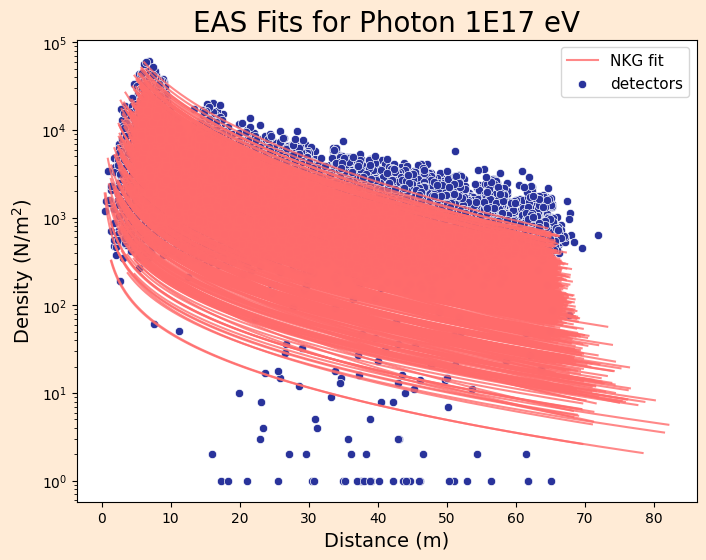

In [109]:
fig, ax = plt.subplots(figsize=(8, 6), facecolor='#FFEBD6')
plt.title(f'EAS Fits for {name} eV', size=20)
ax.set_xlabel('Distance (m)', size=14)
ax.set_ylabel('Density (N/m$^2$)', size=14)
ax.set_facecolor('white')
ax.set_yscale('log')

for i, row in enumerate(parameters_df.iter_rows(named=True)):  
    C = row['C']
    a = row['a']
    b = row['b']
    
    # Gera pontos suaves para a curva
    r_smooth = np.linspace(min(x[i]), max(x[i]), 300)
    rho_fit = model(r_smooth, C, a, b)
    
    # Plota a curva de ajuste
    label_fit = 'NKG fit' if i == 0 else None
    sns.lineplot(x=r_smooth, y=rho_fit, color='#FF6B6B', ax=ax, 
                 label=label_fit, alpha = 0.8)
    
    # Plota os pontos dos detectores
    label_scatter = 'detectors' if i == 0 else None
    sns.scatterplot(x=x[i], y=y[i], color='#29339B', ax=ax, 
                    label=label_scatter)

ax.legend(
    loc='upper right',
    fontsize=11,
    frameon=True,
    facecolor='white',
)

plt.show()

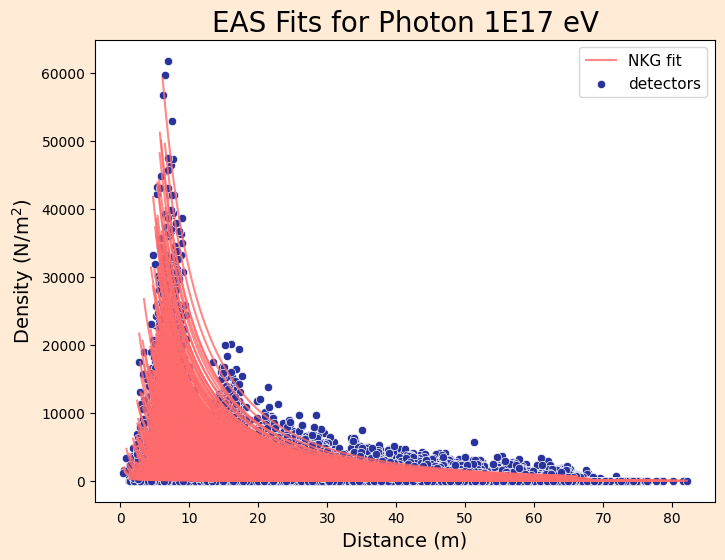

In [110]:
fig, ax = plt.subplots(figsize=(8, 6), facecolor='#FFEBD6')
plt.title(f'EAS Fits for {name} eV', size=20)
ax.set_xlabel('Distance (m)', size=14)
ax.set_ylabel('Density (N/m$^2$)', size=14)
ax.set_facecolor('white')

for i, row in enumerate(parameters_df.iter_rows(named=True)):  
    C = row['C']
    a = row['a']
    b = row['b']
    
    # Gera pontos suaves para a curva
    r_smooth = np.linspace(min(x[i]), max(x[i]), 300)
    rho_fit = model(r_smooth, C, a, b)
    
    # Plota a curva de ajuste
    label_fit = 'NKG fit' if i == 0 else None
    sns.lineplot(x=r_smooth, y=rho_fit, color='#FF6B6B', ax=ax, 
                 label=label_fit, alpha = 0.8)
    
    # Plota os pontos dos detectores
    label_scatter = 'detectors' if i == 0 else None
    sns.scatterplot(x=x[i], y=y[i], color='#29339B', ax=ax, 
                    label=label_scatter)

ax.legend(
    loc='upper right',
    fontsize=11,
    frameon=True,
    facecolor='white',
)

plt.show()

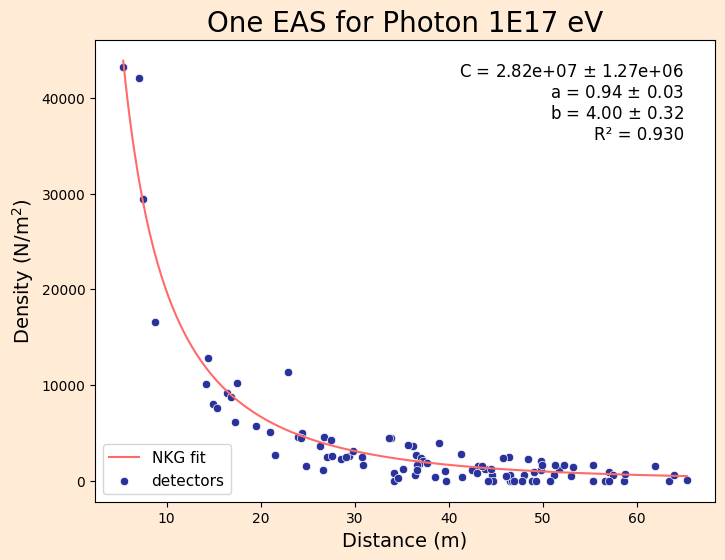

In [111]:
fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
plt.title('One EAS for ' + str(name) + ' eV', size = 20)
#fig.tight_layout()


#ax.set_title('log C x log E', size = 15)
ax.set_xlabel('Distance (m)', size = 14)
ax.set_ylabel('Density (N/m$^2$)', size = 14)
ax.set_facecolor('white')

i = 200

C = parameters_df['C'][i]
a = parameters_df['a'][i]
b = parameters_df['b'][i]
C_err = parameters_df['C_err'][i]
a_err = parameters_df['a_err'][i]
b_err = parameters_df['b_err'][i]

r_smooth = np.linspace(min(x[i]), max(x[i]), 300)
rho_fit = model(r_smooth, C, a, b)

sns.lineplot(x=r_smooth, y=rho_fit, color='#FF6B6B', ax=ax, label='NKG fit')

sns.scatterplot(x = x[i], y = y[i], color = '#29339B', ax = ax, label = 'detectors')

textstr = f'C = {C:.2e} $\pm$ {C_err:.2e}\na = {a:.2f} $\pm$ {a_err:.2f}\nb = {b:.2f} $\pm$ {b_err:.2f}\nR² = {parameters_df["R_2"][i]:.3f}'

ax.text(0.95, 0.95, textstr, transform=ax.transAxes,
        verticalalignment='top', horizontalalignment='right',
        fontsize = 12
        )

ax.legend(
    loc='lower left',
    fontsize=11,
    frameon=True,
    facecolor='white',
)

plt.show()


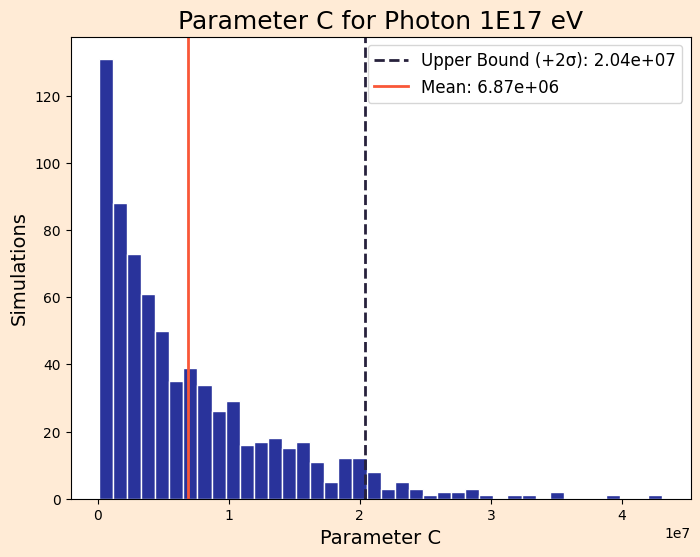

In [112]:
fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
plt.hist(parameters_df['C'], color='#29339B', bins= 40, edgecolor = 'white')
plt.ylabel('Simulations')
plt.xlabel('C')
plt.title('Parameter C for ' + str(name) + ' eV', size = 18)
#plt.grid(True)

# Calcula a média e o desvio padrão dos dados
mean = parameters_df['C'].mean()
std = parameters_df['C'].std()

# Determina os limites de 2 sigma
#lower_bound = mean - 2 * std
upper_bound = mean + 2 * std


# Adiciona linhas verticais para os limites de 2 sigma
#ax.axvline(lower_bound, color='#548C2F', linestyle='--', linewidth=2, label=f'Lower Bound (-2σ): {lower_bound:.2f}')
ax.axvline(upper_bound, color='#27213C', linestyle='--', linewidth=2, label=f'Upper Bound (+2σ): {upper_bound:.2e}')
ax.axvline(mean, color='#F95738', linestyle='-', linewidth=2, label=f'Mean: {mean:.2e}')

# Personaliza o eixo e a legenda
ax.set_xlabel('Parameter C', size=14)
ax.set_ylabel('Simulations', size=14)
ax.legend(loc='upper right', fontsize=12)

#plt.savefig('plots/' + name.split(' ')[0].lower() + '/par_c_' + caminho_arquivo.split('/')[-1] + '_array.png', bbox_inches = 'tight')

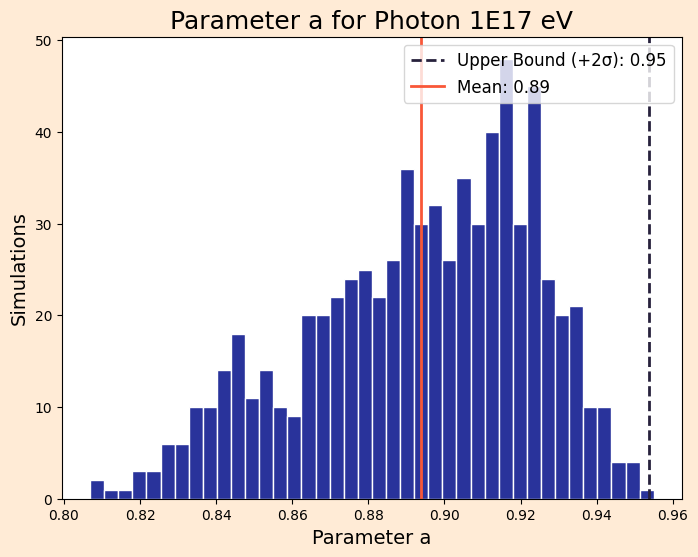

In [113]:
fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
plt.hist(parameters_df['a'], color='#29339B', bins= 40, edgecolor = 'white')
plt.ylabel('Simulations')
plt.xlabel('a')
plt.title('Parameter a for ' + str(name) + ' eV', size = 18)
#plt.grid(True)

# Calcula a média e o desvio padrão dos dados
mean = parameters_df['a'].mean()
std = parameters_df['a'].std()

# Determina os limites de 2 sigma
#lower_bound = mean - 2 * std
upper_bound = mean + 2 * std


# Adiciona linhas verticais para os limites de 2 sigma
#ax.axvline(lower_bound, color='#548C2F', linestyle='--', linewidth=2, label=f'Lower Bound (-2σ): {lower_bound:.2f}')
ax.axvline(upper_bound, color='#27213C', linestyle='--', linewidth=2, label=f'Upper Bound (+2σ): {upper_bound:.2f}')
ax.axvline(mean, color='#F95738', linestyle='-', linewidth=2, label=f'Mean: {mean:.2f}')

# Personaliza o eixo e a legenda
ax.set_xlabel('Parameter a', size=14)
ax.set_ylabel('Simulations', size=14)
ax.legend(loc='upper right', fontsize=12)

#plt.savefig('plots/' + name.split(' ')[0].lower() + '/par_a_' + caminho_arquivo.split('/')[-1] + '_array.png', bbox_inches = 'tight')

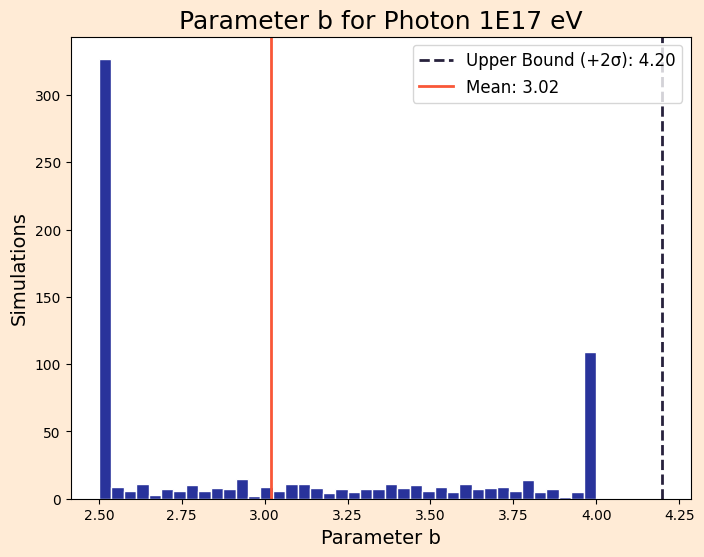

In [114]:
fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
plt.hist(parameters_df['b'], color='#29339B', bins= 40, edgecolor = 'white')
plt.ylabel('Simulations')
plt.xlabel('a')
plt.title('Parameter b for ' + str(name) + ' eV', size = 18)
#plt.grid(True)

# Calcula a média e o desvio padrão dos dados
mean = parameters_df['b'].mean()
std = parameters_df['b'].std()

# Determina os limites de 2 sigma
#lower_bound = mean - 2 * std
upper_bound = mean + 2 * std


# Adiciona linhas verticais para os limites de 2 sigma
#ax.axvline(lower_bound, color='#548C2F', linestyle='--', linewidth=2, label=f'Lower Bound (-2σ): {lower_bound:.2f}')
ax.axvline(upper_bound, color='#27213C', linestyle='--', linewidth=2, label=f'Upper Bound (+2σ): {upper_bound:.2f}')
ax.axvline(mean, color='#F95738', linestyle='-', linewidth=2, label=f'Mean: {mean:.2f}')

# Personaliza o eixo e a legenda
ax.set_xlabel('Parameter b', size=14)
ax.set_ylabel('Simulations', size=14)
ax.legend(loc='upper right', fontsize=12)

#plt.savefig('plots/' + name.split(' ')[0].lower() + '/par_b_' + caminho_arquivo.split('/')[-1] + '_array.png', bbox_inches = 'tight')

Text(0, 0.5, 'Simulations')

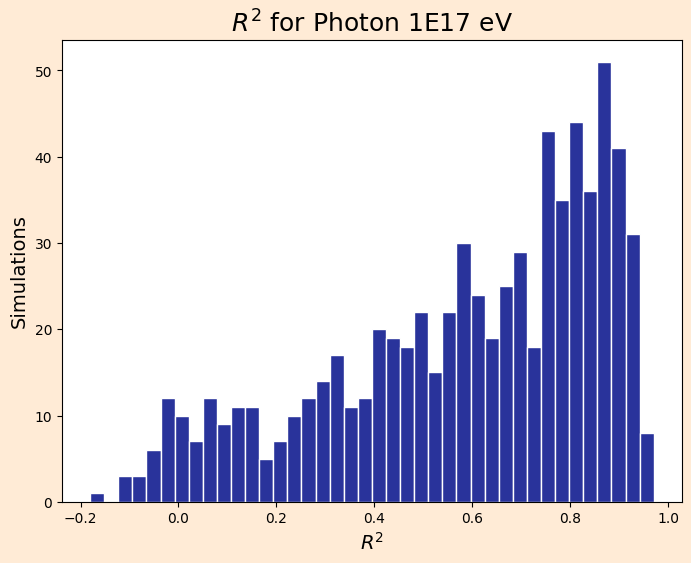

In [115]:
fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
plt.hist(parameters_df['R_2'], color='#29339B', bins= 40, edgecolor = 'white')
plt.ylabel('Simulations')
plt.xlabel('$R^2$')
plt.title('$R^2$ for ' + str(name) + ' eV', size = 18)
#plt.grid(True)

ax.set_xlabel('$R^2$', size=14)
ax.set_ylabel('Simulations', size=14)

#plt.savefig('plots/' + name.split(' ')[0].lower() + '/rsquared_' + caminho_arquivo.split('/')[-1] + '_array.png', bbox_inches = 'tight')

Text(0, 0.5, 'Simulations')

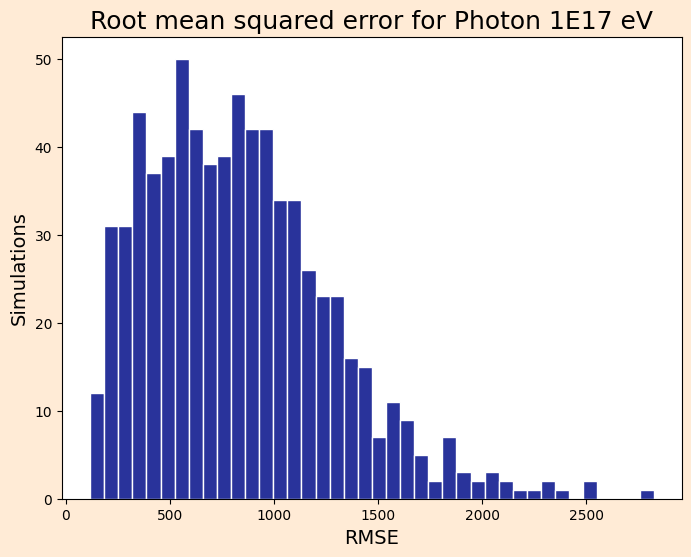

In [116]:
fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
plt.hist(parameters_df['RMSE'], color='#29339B', bins= 40, edgecolor = 'white')
plt.ylabel('Simulations')
plt.xlabel('RMSE')
plt.title('Root mean squared error for ' + str(name) + ' eV', size = 18)
#plt.grid(True)

ax.set_xlabel('RMSE', size=14)
ax.set_ylabel('Simulations', size=14)

#plt.savefig('plots/' + name.split(' ')[0].lower() + '/rmse_' + caminho_arquivo.split('/')[-1] + '_array.png', bbox_inches = 'tight')

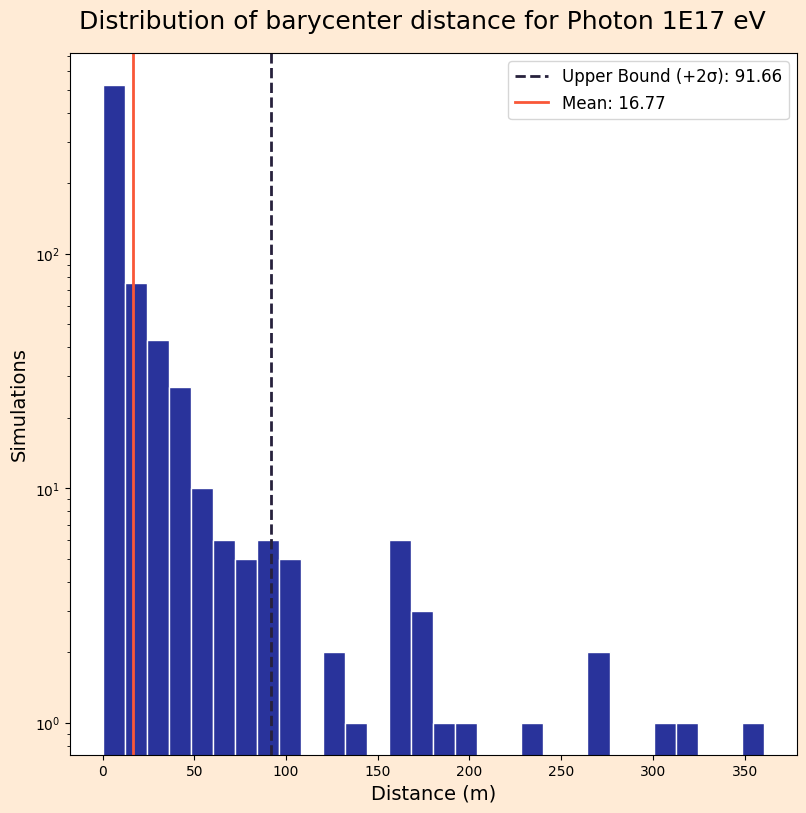

In [117]:
fig, ax = plt.subplots(1, 1, figsize = (8, 8), facecolor = '#FFEBD6')
fig.suptitle('Distribution of barycenter distance for ' + str(name) + ' eV', size = 18)
fig.tight_layout()
ax.set_yscale('log')

# Calcula a média e o desvio padrão dos dados
mean = df['r_b'].mean()
std = df['r_b'].std()

# Determina os limites de 2 sigma
#lower_bound = mean - 2 * std
upper_bound = mean + 2 * std

plt.hist(df['r_b'], color = '#29339B', edgecolor = 'white', bins = 30)

# Adiciona linhas verticais para os limites de 2 sigma
#ax.axvline(lower_bound, color='#548C2F', linestyle='--', linewidth=2, label=f'Lower Bound (-2σ): {lower_bound:.2f}')
ax.axvline(upper_bound, color='#27213C', linestyle='--', linewidth=2, label=f'Upper Bound (+2σ): {upper_bound:.2f}')
ax.axvline(mean, color='#F95738', linestyle='-', linewidth=2, label=f'Mean: {mean:.2f}')

# Personaliza o eixo e a legenda
ax.set_xlabel('Distance (m)', size=14)
ax.set_ylabel('Simulations', size=14)
ax.legend(loc='upper right', fontsize=12)

#plt.savefig('plots/' + name.split(' ')[0].lower() + '/barycenter_' + caminho_arquivo.split('/')[-1] + '_array.png', bbox_inches = 'tight')

[4.78456386e-16 1.62405708e-02]
[4.2341922  4.87817914 5.52297264 6.16695958 6.81175308]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_25436\2980915457.py:23: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
C:\Users\Lucas\AppData\Local\Temp\ipykernel_25436\2980915457.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
4.207096,15.0,14.978975,0.140167
4.905418,15.499687,15.520823,0.13636
5.541205,16.0,16.014147,0.088417
6.157154,16.499687,16.492079,0.04611
6.803184,17.0,16.993351,0.039112


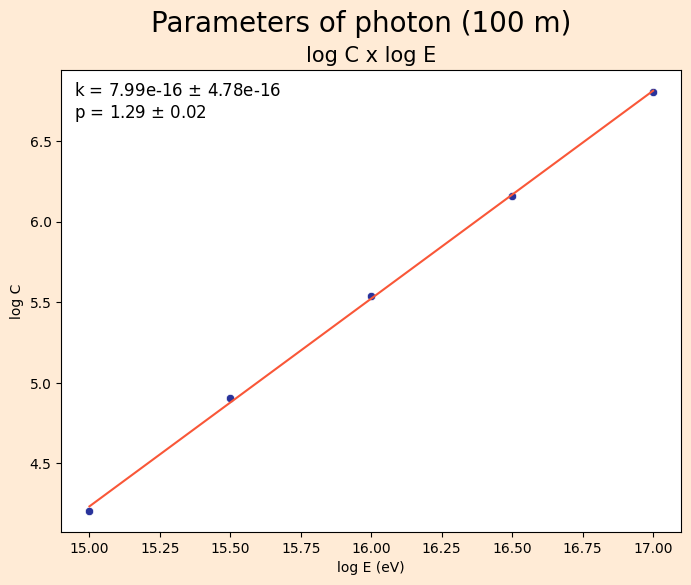

In [118]:
# Fit do fóton

C = [1.611e+04, 8.043e+04, 3.477e+05, 1.436e+06, 6.356e+06]
E = [1E15, 3.16E15, 1E16, 3.16E16, 1E17]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of photon (100 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_photon, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(E,*coefficients_photon))

ax.plot(logE, power(E,*coefficients_photon), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#29339B', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_photon[0],inc[0],coefficients_photon[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients_photon[0]))/coefficients_photon[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

In [119]:
k_photon = coefficients_photon[0] #- inc[0]
p_photon = coefficients_photon[1] #- inc[1]
c_photon = parameters_df['C'] #- parameters_df['C_err']

E_photon = []
E_real = float(name.split(' ')[1])

erro_relativo = []
erro_absoluto = []

for i in range(len(c_photon)):
    E = (c_photon[i] / k_photon) ** (1 / p_photon)
    E_photon.append(E)
    
    # Calcular erro absoluto
    erro_abs = abs(E - E_real)
    erro_absoluto.append(erro_abs)
    
    # Calcular erro relativo (em porcentagem)
    erro_rel = (erro_abs / E_real) * 100
    erro_relativo.append(erro_rel)

data = {
    'E':E_photon,
    'Relative_error':erro_relativo,
    'Absolute_error':erro_absoluto
}

df3 = pl.DataFrame(data)
df3

E,Relative_error,Absolute_error
f64,f64,f64
2.6380e16,73.620044,7.3620e16
1.3546e17,35.4578,3.5458e16
6.3269e16,36.730798,3.6731e16
2.4775e17,147.747662,1.4775e17
3.2753e16,67.247414,6.7247e16
…,…,…
3.7134e17,271.337538,2.7134e17
5.1808e16,48.191562,4.8192e16
1.0837e17,8.372455,8.3725e15


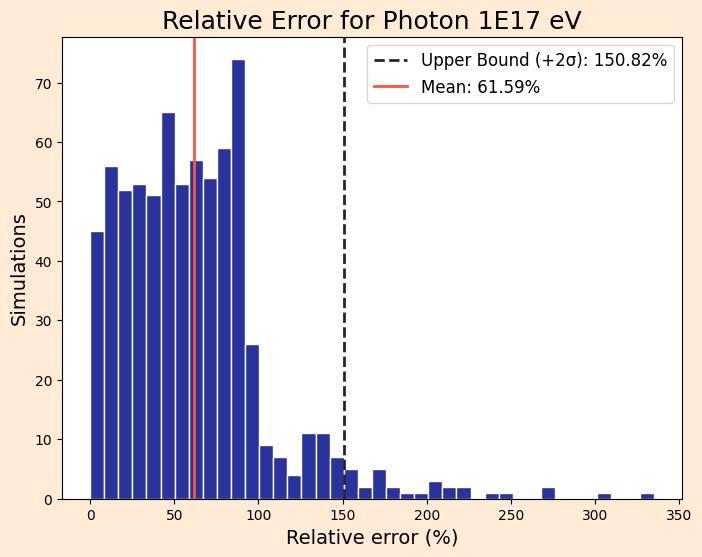

In [120]:
fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
plt.hist(erro_relativo, color='#29339B', bins= 40, edgecolor = 'white')
plt.ylabel('Simulations')
plt.xlabel('Relative Error (%)')
plt.title('Relative Error for ' + str(name) + ' eV', size = 18)
#plt.grid(True)

# Calcula a média e o desvio padrão dos dados
mean = df3['Relative_error'].mean()
std = df3['Relative_error'].std()

# Determina os limites de 2 sigma
#lower_bound = mean - 2 * std
upper_bound = mean + 2 * std


# Adiciona linhas verticais para os limites de 2 sigma
#ax.axvline(lower_bound, color='#548C2F', linestyle='--', linewidth=2, label=f'Lower Bound (-2σ): {lower_bound:.2f}')
ax.axvline(upper_bound, color='#27213C', linestyle='--', linewidth=2, label=f'Upper Bound (+2σ): {upper_bound:.2f}%')
ax.axvline(mean, color='#F95738', linestyle='-', linewidth=2, label=f'Mean: {mean:.2f}%')

# Personaliza o eixo e a legenda
ax.set_xlabel('Relative error (%)', size=14)
ax.set_ylabel('Simulations', size=14)
ax.legend(loc='upper right', fontsize=12)

#plt.savefig('plots/' + name.split(' ')[0].lower() +'/energy_'+ caminho_arquivo.split('/')[-1] + '_array.png',bbox_inches = 'tight')

In [121]:
from uncertainties import ufloat
import uncertainties.umath as umath

k_value = coefficients_photon[0]
k_error = inc[0]  
p_value = coefficients_photon[1]
p_error = inc[1]  

k_photon = ufloat(k_value, k_error)
p_photon = ufloat(p_value, p_error)

c_photons = [ufloat(c, c_err) for c, c_err in zip(parameters_df['C'], parameters_df['C_err'])]

E_photon_with_errors = []

E_real = float(name.split(' ')[1])

for c in c_photons:
    E = (c / k_photon) ** (1 / p_photon)
    E_photon_with_errors.append(E)


E_nominal = [e.nominal_value for e in E_photon_with_errors]
E_error = [e.std_dev for e in E_photon_with_errors]

erro_absoluto = [abs(e.nominal_value - E_real) for e in E_photon_with_errors]
erro_relativo = [(erro / E_real) * 100 for erro in erro_absoluto]


data = {
    'E': E_nominal,
    'Propagated_uncertainty': E_error,
    'Absolute_error': erro_absoluto,
    'Relative_error': erro_relativo    
}

df3 = pl.DataFrame(data)

df3

E,Propagated_uncertainty,Absolute_error,Relative_error
f64,f64,f64,f64
2.6380e16,1.7981e16,7.3620e16,73.620044
1.3546e17,9.2485e16,3.5458e16,35.4578
6.3269e16,4.3158e16,3.6731e16,36.730798
2.4775e17,1.7044e17,1.4775e17,147.747662
3.2753e16,2.2210e16,6.7247e16,67.247414
…,…,…,…
3.7134e17,2.5629e17,2.7134e17,271.337538
5.1808e16,3.5118e16,4.8192e16,48.191562
1.0837e17,7.3832e16,8.3725e15,8.372455


(-1.951919793999987e+17, 6.331278017802281e+17)

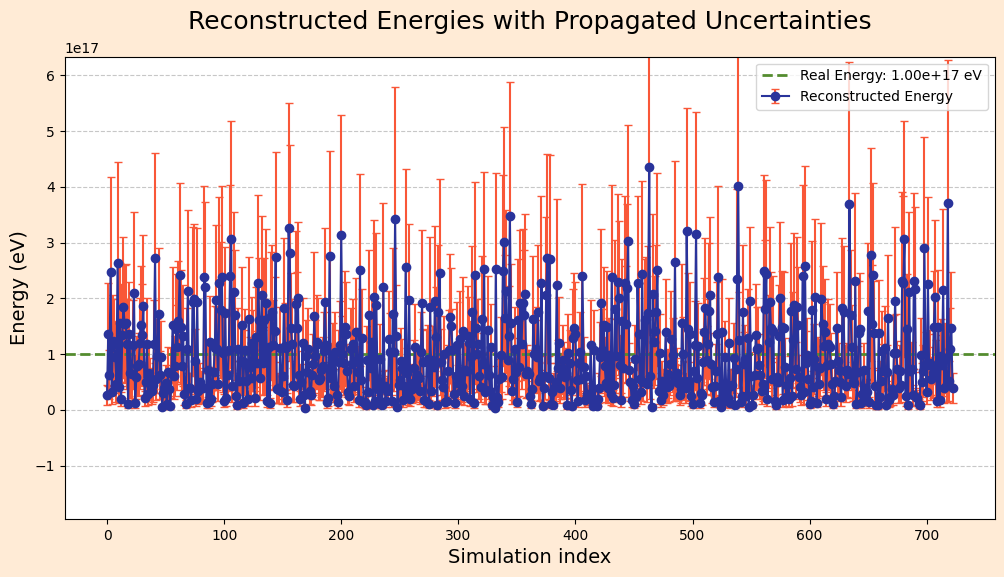

In [122]:
x = np.arange(len(E_nominal))  

plt.figure(figsize=(12, 6), facecolor='#FFEBD6')
ax = plt.gca()

plt.errorbar(
    x,
    E_nominal,
    yerr=E_error,
    fmt='-o',           
    color='#29339B',    
    ecolor='#F95738',   
    elinewidth=1.5,    
    capsize=3,          
    #alpha=0.7,          
    label='Reconstructed Energy'
)

plt.axhline(
    E_real,
    color='#548C2F',
    linestyle='--',
    linewidth=2,
    label=f'Real Energy: {E_real:.2e} eV'
)

plt.xlabel('Simulation index', size=14)
plt.ylabel('Energy (eV)', size=14)
plt.title('Reconstructed Energies with Propagated Uncertainties', size=18, pad=20)

# Adicionar legenda e grid
plt.legend(loc='upper right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.ylim(
    min(E_nominal) - 3 * np.mean(E_error),
    max(E_nominal) + 3 * np.mean(E_error)
)


#plt.savefig('plots/' + name.split(' ')[0].lower() +'/energy_error'+ caminho_arquivo.split('/')[-1] + '_array.png',bbox_inches = 'tight')